Matplotlib is building the font cache; this may take a moment.


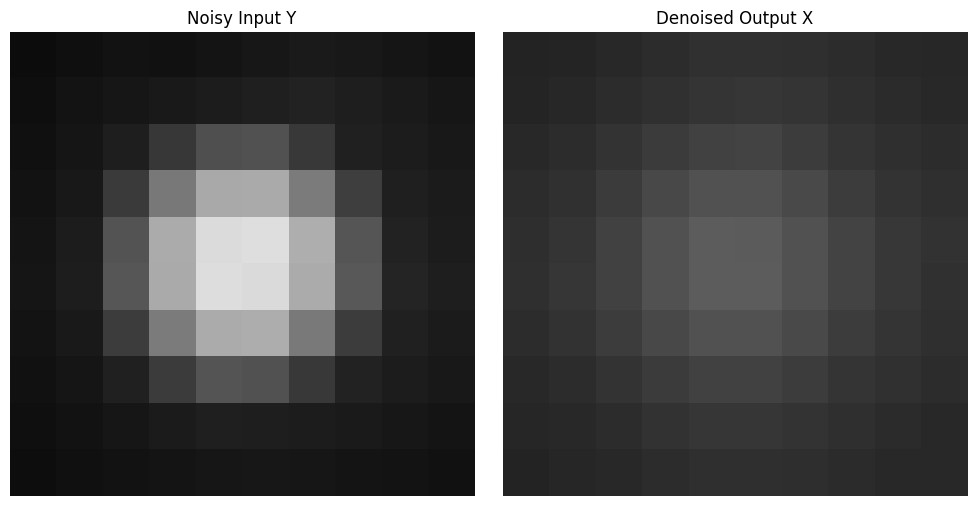

In [1]:
import numpy as np
import matplotlib.pyplot as plt

CONST_VALUE_MIN = 0
CONST_VALUE_MAX = 255

# Step 1: Noisy image Y
def noisy_image_Y():
    image = np.array([
      [12.4, 15.1, 18.7, 17.9, 20.2, 23.8, 26.0, 24.1, 21.3, 18.9],
      [14.8, 19.5, 22.2, 25.7, 28.0, 31.2, 33.9, 30.4, 26.8, 22.0],
      [16.9, 21.0, 30.5, 55.2, 79.1, 82.4, 57.6, 33.1, 28.2, 24.6],
      [18.2, 24.3, 58.7, 120.5, 168.9, 170.1, 123.4, 62.2, 31.6, 26.9],
      [20.1, 28.8, 83.4, 171.2, 219.0, 221.5, 173.8, 85.1, 34.0, 28.3],
      [21.0, 29.6, 86.1, 169.8, 220.7, 218.1, 170.5, 87.9, 36.2, 29.9],
      [19.4, 25.7, 60.9, 122.8, 171.0, 172.6, 121.4, 61.0, 33.0, 27.4],
      [17.0, 21.8, 32.9, 59.4, 84.0,  80.7,  56.8,  34.2, 28.8, 24.9],
      [15.6, 18.9, 22.6, 27.8, 31.5,  30.0,  28.1,  26.5, 23.4, 20.6],
      [13.9, 16.0, 18.3, 20.5, 22.9,  23.1,  22.0,  20.7, 19.1, 17.2]
  ])
    return image

# Step 2: Gibbs sampling for image denoising
def gibbs_sampling(noisy_obs, sigma = 25, lambda_param=0.01, sweeps=500, burn_in=200, seed = 0):
    """
    Gaussian denoising:
      x_ij ∈ {0,1}
      y_ij ~ N(x_ij, sigma^2)
      prior prefers agreement with 4-neighbors
    """
    rng = np.random.default_rng(seed)
    H, W = noisy_obs.shape

    # init from observation so the square doesn't disappear
    x = noisy_obs.copy() 

    # degree (# of valid 4-neighbors) per pixel (edges/corners smaller)
    deg = np.full((H, W), 4, dtype=np.float64)
    deg[0, :] -= 1
    deg[-1, :] -= 1
    deg[:, 0] -= 1
    deg[:, -1] -= 1

    acc = np.zeros((H, W), dtype=np.float64)
    acc_count = 0

    def neighbor_sum(curr):
        nsum = np.zeros_like(curr, dtype=np.float64)
        nsum[1:, :]  += curr[:-1, :]   # up
        nsum[:-1, :] += curr[1:, :]    # down
        nsum[:, 1:]  += curr[:, :-1]   # left
        nsum[:, :-1] += curr[:, 1:]    # right
        return nsum
    
    sigma2 = sigma ** 2
    
    for s in range(sweeps):
        # scanline order
        for i in range(H):
          for j in range(W):
            # compute conditional distribution p(x_ij | x_-ij, y)
            nsum = neighbor_sum(x)
            v = 1.0 / (1.0 / sigma2 + lambda_param * deg[i, j]) 
            mu = v * (noisy_obs[i, j] / sigma2 + lambda_param * nsum[i, j])
            
            # N(mu,v)
            x[i, j] = rng.normal(mu, np.sqrt(v))
            
        # average samples after burn-in (this is what makes it look “denoised” instead of noisy)
        if s >= burn_in:
            acc += x
            acc_count += 1

    # compute final denoised estimate by averageing 300 samples images pixelwise
    post_mean = acc / max(acc_count, 1)
    return post_mean

# --- run ---
noisy_image_Y = noisy_image_Y()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Display the noisy image Y
axes[0].imshow(noisy_image_Y, cmap='gray', vmin=CONST_VALUE_MIN, vmax=CONST_VALUE_MAX)
axes[0].set_title("Noisy Input Y"); axes[0].axis('off')

# Count and display the denoised image X
denoised_image_X = gibbs_sampling(noisy_image_Y, sigma = 25, lambda_param=0.01, sweeps=500, burn_in=200, seed = 0)
axes[1].imshow(denoised_image_X, cmap='gray', vmin=CONST_VALUE_MIN, vmax=CONST_VALUE_MAX)
axes[1].set_title("Denoised Output X"); axes[1].axis('off')
plt.tight_layout()
plt.show()